In [1]:
import numpy as np
from pandas import read_csv
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from src.photonuclear_cross_sections import *

### Creating a instance of the Giant Dipole Resonance model

In [2]:
gdr_model = GDR_atlas()

### Creating a instance of the Puget-Stecker-Bredekamp model of cross sections

In [3]:
psb_model = PSB_model()

### Creating a instance of SimPropv2.4 model M1 of cross sections

In [4]:
sim_model = SimProp_model()

### Comparing cross sections

(0.1, 200)

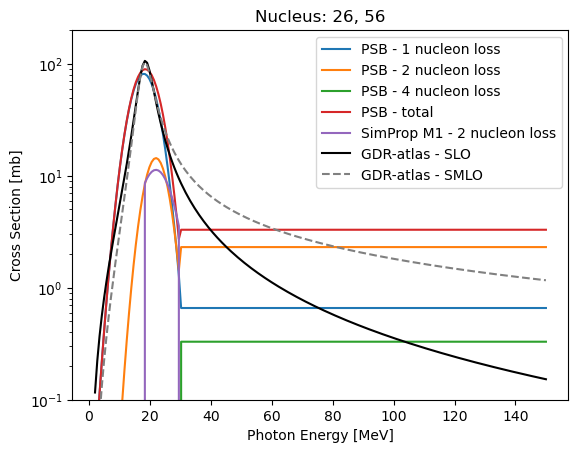

In [5]:
Z, A = 26, 56
eps = np.linspace(2, 150, 200)

psb_tot = np.zeros_like(eps)
for nloss in [1, 2, 4]:
    psb_tot += psb_model.cross_section(eps, Z, A, nloss)
    plt.plot(eps, psb_model.cross_section(eps, Z, A, nloss), label=f'PSB - {nloss} nucleon loss')
plt.plot(eps, psb_tot, label=f'PSB - total')
    
nloss = 2
plt.plot(eps, sim_model.cross_section(eps, Z, A, nloss), label=f'SimProp M1 - {nloss} nucleon loss')

plt.plot(eps, gdr_model.sigma_gdr(eps, Z, A), c='k', label='GDR-atlas - SLO')
plt.plot(eps, gdr_model.sigma_gdr(eps, Z, A, 'smlo'), c='grey', ls='--', label='GDR-atlas - SMLO')

plt.legend()
plt.title(f'Nucleus: {Z}, {A}')
plt.xlabel('Photon Energy [MeV]')
plt.ylabel('Cross Section [mb]')
plt.semilogy()
plt.ylim(1e-1, 200)

### Comparing different SimPropv2.4 models

In [ ]:
sim_model_M1 = SimProp_model(M=1)
sim_model_M2 = SimProp_model(M=2, filename='xsect_BreitWigner_TALYS-1.0.txt')
sim_model_M3 = SimProp_model(M=3)
sim_model_M4 = SimProp_model(M=4)

Text(0, 0.5, 'Cross Section [mb]')

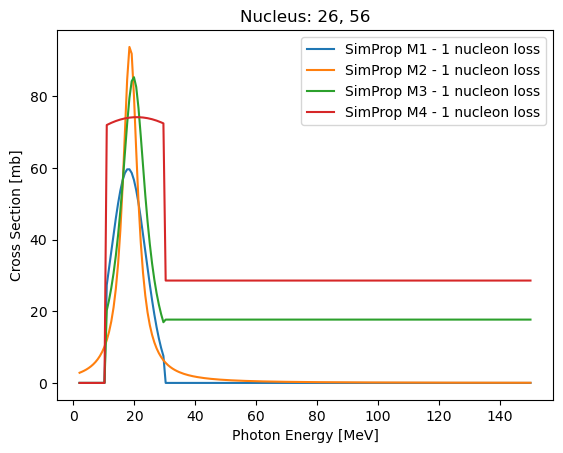

In [13]:
nloss = 1

for sm in [sim_model_M1, sim_model_M2, sim_model_M3, sim_model_M4]:
    plt.plot(eps, sm.cross_section(eps, Z, A, nloss), label=f'SimProp M{sm.M} - {nloss} nucleon loss')

plt.legend()
plt.title(f'Nucleus: {Z}, {A}')
plt.xlabel('Photon Energy [MeV]')
plt.ylabel('Cross Section [mb]')